# Modelo de Precificação de Aluguéis — São Carlos

Predição do preço de aluguel de imóveis na cidade de São Carlos (SP) usando dados coletados de múltiplas imobiliárias locais.

| | |
|---|---|
| **Fontes** | Cardinali, Roca, Center, Abias, Sape |
| **Alvo** | `preco_locacao` (R$) |
| **Modelos** | LightGBM, Random Forest, KNN |
| **Otimização** | Optuna (busca bayesiana de hiperparâmetros) |

In [168]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import TargetEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_validate
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from lightgbm import LGBMRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

## 1. Carregamento dos Dados

Combina os CSVs históricos (pasta `data/antigo`) com os dados mais recentes (`data/`). Em caso de duplicatas por `codigo`, mantém a linha com mais campos preenchidos.

In [169]:
OUTPUT_DIR = Path('../data')
OUTPUT_DIR_ANT = Path('../data/antigo')

fontes = ['cardinali', 'roca', 'center', 'abias', 'sape']

dfs = []
for f in fontes:
    ant = pd.read_csv(OUTPUT_DIR_ANT / f'{f}.csv')
    novo = pd.read_csv(OUTPUT_DIR / f'{f}.csv')
    
    combinado = pd.concat([ant, novo], ignore_index=True)
    
    combinado['_preenchidos'] = combinado.notna().sum(axis=1)
    
    combinado = combinado.sort_values('_preenchidos').drop_duplicates(subset=['codigo'], keep='last')
    combinado = combinado.drop(columns=['_preenchidos'])
    
    print(f'{f:12s}: antigo={len(ant):5d}, novo={len(novo):5d} -> combinado={len(combinado):5d}')
    dfs.append(combinado)

df = pd.concat(dfs, ignore_index=True)
print(f'\ntotal: {len(df)} linhas')
df.head(1)

cardinali   : antigo= 4232, novo= 3417 -> combinado= 4367
roca        : antigo= 2438, novo= 2428 -> combinado= 2486
center      : antigo=  678, novo=  680 -> combinado=  680
abias       : antigo=  274, novo=  279 -> combinado=  281
sape        : antigo= 1035, novo= 1035 -> combinado= 1026

total: 8840 linhas


,fonte,codigo,titulo,tipo,subtipo,finalidade,preco_locacao,preco_venda,valor_condominio,valor_iptu,...,banheiros,garagens,area_total,area_construida,area_util,area_terreno,descricao,url,latitude,longitude
0,Cardinali,26668,Terreno no Parque Eco-Tecnológico Damha I em S...,Terreno,Padrao,Locacao,NaN,NaN,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Gostaria de alugar um Terreno no Parque Eco-Te...,https://www.cardinali.com.br/alugar/Sao-Carlos...,NaN,NaN


### Visão Geral do Dataset Bruto

In [170]:
df.info(verbose=True, show_counts=True, buf=buf)


In [171]:
df.describe()

,codigo,endereco,dormitorios,suites,banheiros,garagens,area_total,area_construida,area_util,area_terreno,latitude,longitude
count,8840.000000,0.0,5941.000000,2765.000000,7390.000000,5818.000000,4.016000e+03,4366.000000,5114.000000,2453.000000,7534.000000,7534.000000
mean,118147.223416,NaN,2.287662,17.510727,1.722192,2.220179,1.623480e+03,233.099279,158.697067,1013.046633,-22.030213,-47.859991
std,85803.345260,NaN,1.107169,228.831687,1.435898,3.018109,2.498020e+04,821.068293,659.126749,5269.788228,0.742083,0.947473
min,3.000000,NaN,0.000000,0.000000,0.000000,0.000000,1.000000e+00,0.000000,0.000000,6.000000,-23.824286,-92.927450
25%,38655.250000,NaN,2.000000,0.000000,1.000000,1.000000,4.678000e+01,50.000000,40.020000,150.000000,-22.025135,-47.901821
50%,98944.000000,NaN,2.000000,1.000000,1.000000,2.000000,7.991500e+01,100.000000,60.000000,250.000000,-22.015158,-47.892932
75%,207148.250000,NaN,3.000000,1.000000,2.000000,2.000000,2.500000e+02,200.000000,120.000000,360.000000,-22.000455,-47.882860
max,238120.000000,NaN,11.000000,10000.000000,40.000000,55.000000,1.258400e+06,23846.000000,24200.000000,55000.000000,17.989620,0.000000


## 2. Pré-processamento

### 2.1 Normalização de Texto e Filtros Iniciais

Padroniza strings (lowercase, remoção de acentos, abreviações de bairros como `jd` → `jardim`), depois filtra apenas imóveis de **locação** do tipo **apartamento** ou **casa**.

In [172]:
df.columns = df.columns.str.lower().str.strip()

colunas_texto = ["tipo", "subtipo", "finalidade", "bairro", "cidade", "estado", "fonte"]
for coluna in colunas_texto:
    if coluna in df.columns:
        df[coluna] = df[coluna].astype(str).str.lower().str.strip()
        df[coluna] = df[coluna].str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')

subs = {r'\bjd\b': 'jardim', r'\bj\b': 'jardim', r'\bpq\b': 'parque',
        r'\bvl\b': 'vila', r'\bres\b': 'residencial', r'\bcond\b': 'condominio', r'\bch\b': 'chacara'}
df['bairro'] = df['bairro'].replace(subs, regex=True)
df['bairro'] = df['bairro'].str.replace(r'\s+', ' ', regex=True).str.strip()

if 'finalidade' in df.columns:
    df = df[df["finalidade"] == "locacao"]

if 'tipo' in df.columns:
    df['tipo'] = df['tipo'].replace({'apartamentos': 'apartamento', 'casas': 'casa'})
    df = df[df['tipo'].isin(['apartamento', 'casa'])]

print(f"Filtro tipo/finalidade: {len(df)} linhas")
for fonte, qtd in df['fonte'].value_counts().items():
    print(f"  {fonte:12s}: {qtd} linhas")

Filtro tipo/finalidade: 2091 linhas
  roca        : 802 linhas
  cardinali   : 572 linhas
  center      : 307 linhas
  abias       : 206 linhas
  sape        : 204 linhas


### 2.2 Limpeza e Imputação

Aplica os filtros definitivos e trata valores faltantes:
- Remove coordenadas inválidas e fora da bounding box de São Carlos
- Remove registros sem preço de locação, bairro ou área útil
- Remove outliers extremos (preço > R$15k, área além dos limites por tipo)

In [173]:
def parse_br_money(s):
    s = str(s)
    if s in ['nan', 'None', '', '.', ',']: return np.nan
    s = s.replace('.', '').replace(',', '.')
    return pd.to_numeric(s, errors='coerce')

for col in ['preco_locacao']:
    if col in df.columns: df[col] = df[col].apply(parse_br_money)

for col in ['area_util', 'area_construida', 'area_total']:
    if col in df.columns: df[col] = pd.to_numeric(df[col], errors='coerce')

for col in ['dormitorios', 'banheiros', 'garagens']:
    if col in df.columns: df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

if 'suites' in df.columns:
    df['suites'] = pd.to_numeric(df['suites'], errors='coerce').fillna(0).astype(int)

if 'latitude' in df.columns: df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
if 'longitude' in df.columns: df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')

df.loc[df['latitude'] == 0, 'latitude'] = np.nan
df.loc[df['longitude'] == 0, 'longitude'] = np.nan
df = df.dropna(subset=['latitude', 'longitude'])

# Bounding box São Carlos - remove coordenadas fora da região
df = df[
    (df['latitude'].between(-22.1, -21.9)) &
    (df['longitude'].between(-48.05, -47.8))
]

if 'area_util' in df.columns:
    df['area_util'] = df['area_util'].fillna(df.get('area_construida')).fillna(df.get('area_total'))

df = df.dropna(subset=['preco_locacao', 'bairro', 'area_util'])
df = df[(df['preco_locacao'] > 0) & (df['area_util'] > 5)]
df = df[~((df['tipo'] == 'apartamento') & (df['area_util'] > 500))]
df = df[~((df['tipo'] == 'casa') & (df['area_util'] > 2000))]

# Remove valores absurdos
df = df[df['preco_locacao'] <= 15000]
df = df[df['garagens'] <= 6]
df = df[df['area_util'] <= 500]

# Remove colunas não usadas pelo modelo
df = df.drop(columns=['valor_condominio', 'valor_iptu', 'area_construida', 'area_terreno', 'area_total', 'endereco', 'codigo', 'url', 'estado', 'cidade'], errors='ignore')

df = df.drop_duplicates(subset=['preco_locacao', 'bairro', 'area_util', 'dormitorios', 'banheiros', 'tipo'])

print(f"Limpeza + dedup: {len(df)} linhas")
for fonte, qtd in df['fonte'].value_counts().items():
    print(f"  {fonte:12s}: {qtd} linhas")

Limpeza + dedup: 1352 linhas
  roca        : 689 linhas
  cardinali   : 300 linhas
  center      : 172 linhas
  abias       : 160 linhas
  sape        : 31 linhas


### 2.3 Filtro por Percentil

Remove os 2% mais baratos e 2% mais caros com base no **preço por m²** (aluguel ÷ área útil). Elimina anúncios com valores absurdos que passaram pelos filtros anteriores.

In [174]:
# Filtro robusto usando preço por m²
df['preco_m2_temp'] = df['preco_locacao'] / df['area_util']
Q_low, Q_high = df['preco_m2_temp'].quantile(0.02), df['preco_m2_temp'].quantile(0.98)

df = df[(df['preco_m2_temp'] >= Q_low) & (df['preco_m2_temp'] <= Q_high)]

df = df.drop(columns=['preco_m2_temp'])

print(f"Filtro percentil: {len(df)} linhas")
for fonte, qtd in df['fonte'].value_counts().items():
    print(f"  {fonte:12s}: {qtd} linhas")

Filtro percentil: 1296 linhas
  roca        : 664 linhas
  cardinali   : 288 linhas
  center      : 157 linhas
  abias       : 156 linhas
  sape        : 31 linhas


### 2.4 Diagnóstico: Onde as Linhas São Perdidas

Mostra o impacto de cada filtro aplicado na etapa anterior: quantos registros foram removidos e por qual imobiliária — útil para identificar problemas na coleta de dados.

In [175]:
# === DIAGNÓSTICO: onde cada linha é perdida na limpeza ===
diag = df.copy()
total_inicio = len(diag)

# Parsear valores monetários (ainda são strings neste ponto)
def _parse(s):
    s = str(s)
    if s in ['nan', 'None', '', '.', ',']: return np.nan
    s = s.replace('.', '').replace(',', '.')
    return pd.to_numeric(s, errors='coerce')

for col in ['preco_locacao']:
    if col in diag.columns: diag[col] = diag[col].apply(_parse)
for col in ['area_util', 'area_construida', 'area_total']:
    if col in diag.columns: diag[col] = pd.to_numeric(diag[col], errors='coerce')
for col in ['latitude', 'longitude']:
    if col in diag.columns: diag[col] = pd.to_numeric(diag[col], errors='coerce')

diag.loc[diag['latitude'] == 0, 'latitude'] = np.nan
diag.loc[diag['longitude'] == 0, 'longitude'] = np.nan

# Fallback de área (mesmo do pipeline)
if 'area_util' in diag.columns:
    diag['area_util'] = diag['area_util'].fillna(diag.get('area_construida')).fillna(diag.get('area_total'))

filtros = {
    'lat/lon nulo': diag[['latitude','longitude']].isna().any(axis=1),
    'fora bounding box SC': diag['latitude'].notna() & diag['longitude'].notna() & ~(diag['latitude'].between(-22.1, -21.9) & diag['longitude'].between(-48.05, -47.8)),
    'preco_locacao nulo': diag['preco_locacao'].isna(),
    'bairro nulo': diag['bairro'].isna(),
    'area_util nula': diag['area_util'].isna(),
    'preco_locacao <= 0': (diag['preco_locacao'] <= 0) & diag['preco_locacao'].notna(),
    'area_util <= 5': (diag['area_util'] <= 5) & diag['area_util'].notna(),
    'apt area > 500': (diag['tipo'] == 'apartamento') & (diag['area_util'] > 500),
    'casa area > 2000': (diag['tipo'] == 'casa') & (diag['area_util'] > 2000),
    'preco > 15000': (diag['preco_locacao'] > 15000) & diag['preco_locacao'].notna(),
    'garagens > 6': diag['garagens'] > 6 if 'garagens' in diag.columns else pd.Series(False, index=diag.index),
}

print(f"Total antes da limpeza: {total_inicio} linhas\n")
print(f"{'Filtro':<25s} {'Afetados':>8s}  {'%':>6s}  Por fonte")
print("-" * 90)
for nome, mask in filtros.items():
    n = mask.sum()
    if n > 0:
        por_fonte = diag.loc[mask, 'fonte'].value_counts()
        fonte_str = ', '.join(f"{f}:{q}" for f, q in por_fonte.items())
        print(f"  {nome:<23s} {n:>8d}  {n/total_inicio*100:>5.1f}%  {fonte_str}")

any_filter = pd.DataFrame(filtros).any(axis=1)
print(f"\n  {'Eliminadas (qualquer)':23s} {any_filter.sum():>8d}  {any_filter.sum()/total_inicio*100:>5.1f}%")
print(f"  {'Sobrevivem':23s} {(~any_filter).sum():>8d}  {(~any_filter).sum()/total_inicio*100:>5.1f}%")


Total antes da limpeza: 1296 linhas

Filtro                    Afetados       %  Por fonte
------------------------------------------------------------------------------------------
  preco > 15000                867   66.9%  roca:401, cardinali:189, abias:134, center:119, sape:24

  Eliminadas (qualquer)        867   66.9%
  Sobrevivem                   429   33.1%


### 2.5 Feature Engineering

Cria features derivadas do texto da descrição e da localização geográfica:

| Feature | Descrição |
|---|---|
| `reformado_novo` | Menciona "reformado", "nova", "primeira locação" |
| `mobiliado` | Menciona "mobiliado" ou variações |
| `piscina` / `churrasqueira` | Menção na descrição |
| `area_por_quarto` | Área útil ÷ dormitórios |
| `dist_centro` / `dist_ufscar` / `dist_usp` / `dist_rodoviaria` | Distância em km a pontos de referência |

Bairros com menos de 5 imóveis são agrupados como `"outros"` para evitar overfitting.

In [176]:
desc = df['descricao'].fillna('').astype(str).str.lower() if 'descricao' in df.columns else pd.Series('', index=df.index)

# Features de texto
df['reformado_novo'] = desc.str.contains('reformado|novo|primeira locacao|recem', regex=True).astype(int)
df['mobiliado'] = desc.str.contains('mobiliado|mobilhado|mobilia', regex=True).astype(int)
df['piscina'] = desc.str.contains('piscina', regex=True).astype(int)
df['churrasqueira'] = desc.str.contains('churrasqueira|churrasq', regex=True).astype(int)

df['area_por_quarto'] = (df['area_util'] / df['dormitorios'].clip(lower=1))

if 'latitude' in df.columns and 'longitude' in df.columns:
    KM_DEGREE = 111 
    CENTRO_LAT, CENTRO_LON = -22.0174, -47.8908
    UFSCAR_LAT, UFSCAR_LON = -21.9839, -47.8822
    USP_CAMPUS1_LAT, USP_CAMPUS1_LON = -22.0063, -47.8946
    RODOVIARIA_LAT, RODOVIARIA_LON = -22.0304, -47.8823

    df['dist_centro'] = np.sqrt((df['latitude'] - CENTRO_LAT)**2 + (df['longitude'] - CENTRO_LON)**2) * KM_DEGREE
    df['dist_ufscar'] = np.sqrt((df['latitude'] - UFSCAR_LAT)**2 + (df['longitude'] - UFSCAR_LON)**2) * KM_DEGREE
    df['dist_usp'] = np.sqrt((df['latitude'] - USP_CAMPUS1_LAT)**2 + (df['longitude'] - USP_CAMPUS1_LON)**2) * KM_DEGREE
    df['dist_rodoviaria'] = np.sqrt((df['latitude'] - RODOVIARIA_LAT)**2 + (df['longitude'] - RODOVIARIA_LON)**2) * KM_DEGREE

    colunas_dist = ['dist_centro', 'dist_ufscar', 'dist_usp', 'dist_rodoviaria']
    df[colunas_dist] = df[colunas_dist].fillna(df[colunas_dist].median())

contagem = df['bairro'].value_counts()
df.loc[~df['bairro'].isin(contagem[contagem >= 5].index), 'bairro'] = 'outros'

print(f"Features: {len(df)} linhas")
for fonte, qtd in df['fonte'].value_counts().items():
    print(f"  {fonte:12s}: {qtd} linhas")

Features: 1296 linhas
  roca        : 664 linhas
  cardinali   : 288 linhas
  center      : 157 linhas
  abias       : 156 linhas
  sape        : 31 linhas


## 3. Análise dos Dados Limpos

Estatísticas descritivas e exemplo de linha após todas as etapas de pré-processamento.

In [177]:
colunas_exibir = ['tipo', 'bairro', 'preco_locacao', 'area_util', 'dormitorios', 'banheiros', 
                  'garagens', 'latitude', 'longitude',
                  'reformado_novo',
                  'area_por_quarto', 'dist_centro', 'dist_ufscar', 'dist_usp']
df[[c for c in colunas_exibir if c in df.columns]].describe()

,preco_locacao,area_util,dormitorios,banheiros,garagens,latitude,longitude,reformado_novo,area_por_quarto,dist_centro,dist_ufscar,dist_usp
count,1296.00000,1296.000000,1296.000000,1296.000000,1296.000000,1296.000000,1296.000000,1296.000000,1296.000000,1296.000000,1296.000000,1296.000000
mean,2301.08250,94.143742,2.259259,1.367284,1.328704,-22.010109,-47.895601,0.129630,40.881613,2.309864,3.966255,2.213993
std,1559.97194,73.338923,0.993760,0.937907,1.064692,0.016310,0.017572,0.336025,25.604159,1.637733,1.422280,1.538723
min,400.00000,15.000000,0.000000,0.000000,0.000000,-22.064993,-47.949024,0.000000,7.500000,0.118853,0.948156,0.040099
25%,1334.00000,48.000000,2.000000,1.000000,1.000000,-22.022019,-47.905212,0.000000,25.000000,1.287829,2.908880,1.109078
50%,1889.00000,64.000000,2.000000,1.000000,1.000000,-22.010455,-47.894760,0.000000,33.333333,1.989890,3.922071,1.859273
75%,2778.00000,112.977500,3.000000,2.000000,2.000000,-22.000250,-47.887288,0.000000,49.000000,2.805182,4.774130,2.919391
max,14445.00000,500.000000,10.000000,7.000000,6.000000,-21.953770,-47.804437,1.000000,400.000000,10.640221,12.044695,11.461726


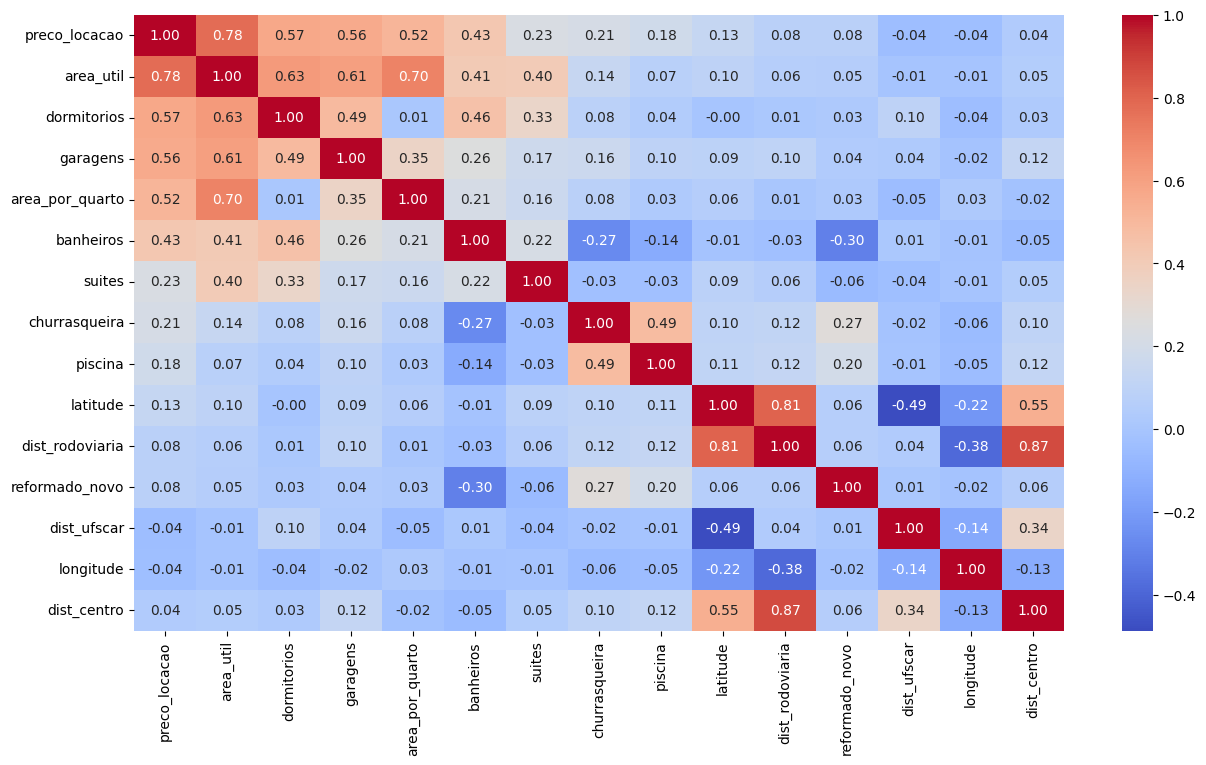

In [178]:
correlacao = df.corr(numeric_only=True)

top_colunas = correlacao['preco_locacao'].abs().nlargest(15).index

plt.figure(figsize=(15, 8))

sns.heatmap(df[top_colunas].corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

## 4. Modelagem

### 4.1 Features e Pré-processador

`bairro` e `tipo` são codificados com **Target Encoding** (substitui a categoria pela média do alvo naquele grupo), evitando alta cardinalidade. As demais features numéricas passam direto (`remainder='passthrough'`).

In [179]:
features_limpas = [
    'tipo', 'area_util', 'bairro', 'area_por_quarto', 'dist_centro',
    'dist_ufscar', 'dist_usp', 'dist_rodoviaria', 'garagens',
    'dormitorios', 'banheiros', 'suites', 'reformado_novo',
    'latitude', 'longitude', 'mobiliado', 'piscina', 'churrasqueira',
]

X = df[features_limpas].copy()
y = df['preco_locacao'].copy()

preprocessor = ColumnTransformer(
    transformers=[
        ('bairro_enc', TargetEncoder(random_state=42), ['bairro']),
        ('tipo_enc', TargetEncoder(random_state=42), ['tipo']),
    ],
    remainder='passthrough'
)

### 4.2 LightGBM — Baseline

Avaliação inicial com hiperparâmetros padrão usando **cross-validation 5-fold**. O alvo é transformado com `log1p` para reduzir o efeito de outliers de preço no treinamento.

In [ ]:
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', TransformedTargetRegressor(
        regressor=LGBMRegressor(
            n_estimators=300, 
            learning_rate=0.05, 
            max_depth=7, 
            num_leaves=31, 
            random_state=42, 
            n_jobs=-1,
            objective='mae',
            verbose=-1
        ),
        func=np.log1p, inverse_func=np.expm1
    ))
])

kf = KFold(n_splits=10, shuffle=True, random_state=42)
res = cross_validate(pipe, X, y, cv=kf, scoring={'mae': 'neg_mean_absolute_error', 'r2': 'r2'})

print("="*60)
print(f"LightGBM - ALVO: ALUGUEL (preco_locacao)")
print("-" * 60)
print(f"MAE Médio: R$ {-res['test_mae'].mean():.2f}")
print(f"MAE Folds: {-np.round(res['test_mae'], 2)}")
print("-" * 60)
print(f"R² Médio:  {res['test_r2'].mean():.3f}")
print(f"R² Folds:  {np.round(res['test_r2'], 3)}")
print("="*60)

/Users/josemaiadeoliveira/rentiq/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/rentiq/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/rentiq/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/rentiq/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM - ALVO: ALUGUEL (preco_locacao)
------------------------------------------------------------
MAE Médio: R$ 523.33
MAE Folds: [555.26 504.18 561.43 481.78 514.02]
------------------------------------------------------------
R² Médio:  0.709
R² Folds:  [0.718 0.748 0.663 0.692 0.724]


/Users/josemaiadeoliveira/rentiq/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


### 4.3 LightGBM — Otimização de Hiperparâmetros (Optuna)

Busca bayesiana com **50 trials** (10-fold CV por trial). Parâmetros otimizados: `n_estimators`, `learning_rate`, `max_depth`, `num_leaves`, `subsample`, `colsample_bytree`, `reg_alpha`, `reg_lambda`.

In [181]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1,
        'objective': 'mae',
        'verbose': -1,
    }

    pipe_opt = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', TransformedTargetRegressor(
            regressor=LGBMRegressor(**params),
            func=np.log1p, inverse_func=np.expm1
        ))
    ])

    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_validate(pipe_opt, X, y, cv=kf, scoring='neg_mean_absolute_error')
    return -scores['test_score'].mean()

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("="*60)
print("Melhores hiperparâmetros encontrados:")
print("-" * 60)
for k, v in study.best_params.items():
    print(f"  {k:22s}: {v}")
print(f"\nMelhor MAE: R$ {study.best_value:.2f}")
print("="*60)

  0%|          | 0/50 [00:00<?, ?it/s]/Users/josemaiadeoliveira/rentiq/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/rentiq/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/rentiq/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/rentiq/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/rentiq/am/.venv/lib/python3.12/site-packages/sklearn/uti

Melhores hiperparâmetros encontrados:
------------------------------------------------------------
  n_estimators          : 1103
  learning_rate         : 0.013955847273776783
  max_depth             : 11
  num_leaves            : 37
  min_child_samples     : 5
  subsample             : 0.63538371890894
  colsample_bytree      : 0.6530039777595971
  reg_alpha             : 0.7415940905851136
  reg_lambda            : 0.3821543896367568

Melhor MAE: R$ 494.11


### 4.4 Random Forest — Otimização de Hiperparâmetros (Optuna)

**200 trials** com 5-fold CV. Parâmetros otimizados: `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`.

In [182]:
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 15),
        'max_features': trial.suggest_float('max_features', 0.3, 1.0),
        'random_state': 42,
        'n_jobs': -1,
    }

    pipe_rf = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', TransformedTargetRegressor(
            regressor=RandomForestRegressor(**params),
            func=np.log1p, inverse_func=np.expm1
        ))
    ])

    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_validate(pipe_rf, X, y, cv=kf, scoring='neg_mean_absolute_error')
    return -scores['test_score'].mean()

study_rf = optuna.create_study(direction='minimize')
study_rf.optimize(objective_rf, n_trials=200, show_progress_bar=True)

print("="*60)
print("Random Forest - Melhores hiperparâmetros:")
print("-" * 60)
for k, v in study_rf.best_params.items():
    print(f"  {k:22s}: {v}")
print(f"\nMelhor MAE: R$ {study_rf.best_value:.2f}")
print("="*60)

Best trial: 174. Best value: 515.846: 100%|██████████| 200/200 [21:09<00:00,  6.35s/it]

Random Forest - Melhores hiperparâmetros:
------------------------------------------------------------
  n_estimators          : 649
  max_depth             : 14
  min_samples_split     : 2
  min_samples_leaf      : 1
  max_features          : 0.33043618974933137

Melhor MAE: R$ 515.85


### 4.5 Random Forest Otimizado — Avaliação Final

In [183]:
best_rf = study_rf.best_params
best_rf.update({'random_state': 42, 'n_jobs': -1})

pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', TransformedTargetRegressor(
        regressor=RandomForestRegressor(**best_rf),
        func=np.log1p, inverse_func=np.expm1
    ))
])

kf = KFold(n_splits=10, shuffle=True, random_state=42)
res_rf = cross_validate(pipe_rf, X, y, cv=kf, scoring={'mae': 'neg_mean_absolute_error', 'r2': 'r2'})

print("="*60)
print(f"Random Forest OTIMIZADO - ALVO: ALUGUEL (preco_locacao)")
print("-" * 60)
print(f"MAE Médio: R$ {-res_rf['test_mae'].mean():.2f}")
print(f"MAE Folds: {-np.round(res_rf['test_mae'], 2)}")
print("-" * 60)
print(f"R² Médio:  {res_rf['test_r2'].mean():.3f}")
print(f"R² Folds:  {np.round(res_rf['test_r2'], 3)}")
print("="*60)

Random Forest OTIMIZADO - ALVO: ALUGUEL (preco_locacao)
------------------------------------------------------------
MAE Médio: R$ 515.85
MAE Folds: [575.23 507.85 515.41 523.74 626.33 526.96 482.95 410.13 546.67 443.18]
------------------------------------------------------------
R² Médio:  0.706
R² Folds:  [0.668 0.743 0.762 0.713 0.641 0.677 0.694 0.708 0.667 0.79 ]


### 4.6 LightGBM Otimizado — Avaliação Final

In [184]:
best = study.best_params
best.update({'random_state': 42, 'n_jobs': -1, 'objective': 'mae', 'verbose': -1})

pipe_l = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', TransformedTargetRegressor(
        regressor=LGBMRegressor(**best),
        func=np.log1p, inverse_func=np.expm1
    ))
])

kf = KFold(n_splits=10, shuffle=True, random_state=42)
res_opt = cross_validate(pipe_l, X, y, cv=kf, scoring={'mae': 'neg_mean_absolute_error', 'r2': 'r2'})

pipe_l.fit(X, y)

print("="*60)
print(f"LightGBM OTIMIZADO - ALVO: ALUGUEL (preco_locacao)")
print("-" * 60)
print(f"MAE Médio: R$ {-res_opt['test_mae'].mean():.2f}")
print(f"MAE Folds: {-np.round(res_opt['test_mae'], 2)}")
print("-" * 60)
print(f"R² Médio:  {res_opt['test_r2'].mean():.3f}")
print(f"R² Folds:  {np.round(res_opt['test_r2'], 3)}")
print("="*60)

/Users/josemaiadeoliveira/rentiq/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/rentiq/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/rentiq/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/rentiq/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/rentiq/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X 

LightGBM OTIMIZADO - ALVO: ALUGUEL (preco_locacao)
------------------------------------------------------------
MAE Médio: R$ 494.11
MAE Folds: [549.25 494.89 485.32 474.67 571.13 506.11 487.41 399.01 523.12 450.19]
------------------------------------------------------------
R² Médio:  0.735
R² Folds:  [0.722 0.739 0.778 0.803 0.715 0.706 0.672 0.712 0.719 0.787]


### 4.7 KNN — Baseline de Comparação

Modelo de k-vizinhos mais próximos como referência simples. Requer `StandardScaler` pois é sensível à escala das features.

In [185]:
pipe_knn = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('regressor', TransformedTargetRegressor(
        regressor=KNeighborsRegressor(n_neighbors=7, weights='distance', n_jobs=-1),
        func=np.log1p, inverse_func=np.expm1
    ))
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
res_knn = cross_validate(pipe_knn, X, y, cv=kf, scoring={'mae': 'neg_mean_absolute_error', 'r2': 'r2'})

print("="*60)
print(f"KNN - ALVO: ALUGUEL (preco_locacao)")
print("-" * 60)
print(f"MAE Médio: R$ {-res_knn['test_mae'].mean():.2f}")
print(f"MAE Folds: {-np.round(res_knn['test_mae'], 2)}")
print("-" * 60)
print(f"R² Médio:  {res_knn['test_r2'].mean():.3f}")
print(f"R² Folds:  {np.round(res_knn['test_r2'], 3)}")
print("="*60)

KNN - ALVO: ALUGUEL (preco_locacao)
------------------------------------------------------------
MAE Médio: R$ 583.79
MAE Folds: [639.32 576.24 679.55 492.06 531.76]
------------------------------------------------------------
R² Médio:  0.612
R² Folds:  [0.556 0.662 0.512 0.642 0.691]


## 5. Importância das Features

Peso relativo de cada feature no modelo LightGBM otimizado (normalizado para somar 1). Quanto maior a barra, mais relevante a feature para prever o preço.

In [186]:
pipe_l.fit(X, y)
feat_names = ['bairro_encoded', 'tipo_encoded'] + [c for c in X.columns if c not in ['bairro', 'tipo']]
importances = pipe_l.named_steps['regressor'].regressor_.feature_importances_
importances = importances / importances.sum()

print("\n=== Peso das Features no Preço (LightGBM) ===")
for n, i in sorted(zip(feat_names, importances), key=lambda x: -x[1]):
    if i > 0.001:
        bar = '█' * int(i * 100)
        print(f"  {n:22s}: {i:.4f} {bar}")


=== Peso das Features no Preço (LightGBM) ===
  area_util             : 0.1237 ████████████
  bairro_encoded        : 0.1146 ███████████
  area_por_quarto       : 0.1112 ███████████
  longitude             : 0.0851 ████████
  dist_ufscar           : 0.0834 ████████
  latitude              : 0.0808 ████████
  dist_centro           : 0.0803 ████████
  dist_usp              : 0.0802 ████████
  dist_rodoviaria       : 0.0661 ██████
  tipo_encoded          : 0.0496 ████
  garagens              : 0.0290 ██
  suites                : 0.0285 ██
  banheiros             : 0.0272 ██
  dormitorios           : 0.0200 ██
  churrasqueira         : 0.0058 
  reformado_novo        : 0.0058 
  mobiliado             : 0.0054 
  piscina               : 0.0035 


## 6. Exportação do Modelo

Salva o pipeline completo (pré-processador + modelo) com `joblib` para uso na API de predição.

In [187]:
import joblib
from pathlib import Path

model_dir = Path('../models')
model_dir.mkdir(exist_ok=True)
joblib.dump(pipe_l, model_dir / 'modelo_aluguel.pkl')
print("Modelo salvo em ../models/modelo_aluguel.pkl")

Modelo salvo em ../models/modelo_aluguel.pkl


## 7. Validação com Imóveis Reais

Teste manual com 3 imóveis conhecidos de São Carlos para verificar se as predições fazem sentido na prática. O valor real do Vila Monteiro (Cardinali) serve como âncora de calibração.

In [188]:
KM_DEGREE = 111
CENTRO_LAT, CENTRO_LON = -22.0174, -47.8908
UFSCAR_LAT, UFSCAR_LON = -21.9839, -47.8822
USP_CAMPUS1_LAT, USP_CAMPUS1_LON = -22.0063, -47.8946
RODOVIARIA_LAT, RODOVIARIA_LON = -22.0304, -47.8823

EMBARE_LAT, EMBARE_LON = -21.9960, -47.8560
VILA_MONTEIRO_LAT, VILA_MONTEIRO_LON = -22.0135, -47.8960

def calc_dist(lat, lon, ref_lat, ref_lon):
    return np.sqrt((lat - ref_lat)**2 + (lon - ref_lon)**2) * KM_DEGREE

imoveis = pd.DataFrame([
    {
        'nome': 'Jardim Embaré - 2q, 1ban, 54m²',
        'tipo': 'apartamento',
        'area_util': 54, 'bairro': 'jardim embare', 'dormitorios': 2, 'banheiros': 1,
        'garagens': 1, 'suites': 0, 'reformado_novo': 0,
        'mobiliado': 0, 'piscina': 0, 'churrasqueira': 0,
        'area_por_quarto': 27,
        'latitude': EMBARE_LAT, 'longitude': EMBARE_LON,
        'dist_centro': calc_dist(EMBARE_LAT, EMBARE_LON, CENTRO_LAT, CENTRO_LON),
        'dist_ufscar': calc_dist(EMBARE_LAT, EMBARE_LON, UFSCAR_LAT, UFSCAR_LON),
        'dist_usp': calc_dist(EMBARE_LAT, EMBARE_LON, USP_CAMPUS1_LAT, USP_CAMPUS1_LON),
        'dist_rodoviaria': calc_dist(EMBARE_LAT, EMBARE_LON, RODOVIARIA_LAT, RODOVIARIA_LON),
    },
    {
        'nome': 'Centro - 2q, 1ban, 50m²',
        'tipo': 'apartamento',
        'area_util': 50, 'bairro': 'centro', 'dormitorios': 2, 'banheiros': 1,
        'garagens': 0, 'suites': 0, 'reformado_novo': 1,
        'mobiliado': 0, 'piscina': 0, 'churrasqueira': 0,
        'area_por_quarto': 25,
        'latitude': CENTRO_LAT, 'longitude': CENTRO_LON,
        'dist_centro': 0,
        'dist_ufscar': calc_dist(CENTRO_LAT, CENTRO_LON, UFSCAR_LAT, UFSCAR_LON),
        'dist_usp': calc_dist(CENTRO_LAT, CENTRO_LON, USP_CAMPUS1_LAT, USP_CAMPUS1_LON),
        'dist_rodoviaria': calc_dist(CENTRO_LAT, CENTRO_LON, RODOVIARIA_LAT, RODOVIARIA_LON),
    },
    {
        'nome': 'Vila Monteiro - 3q, 2ban, 95m² (Cardinali 238063)',
        'tipo': 'apartamento',
        'area_util': 95, 'bairro': 'vila monteiro', 'dormitorios': 3, 'banheiros': 2,
        'garagens': 2, 'suites': 1, 'reformado_novo': 0,
        'mobiliado': 0, 'piscina': 0, 'churrasqueira': 0,
        'area_por_quarto': 95/3,
        'latitude': VILA_MONTEIRO_LAT, 'longitude': VILA_MONTEIRO_LON,
        'dist_centro': calc_dist(VILA_MONTEIRO_LAT, VILA_MONTEIRO_LON, CENTRO_LAT, CENTRO_LON),
        'dist_ufscar': calc_dist(VILA_MONTEIRO_LAT, VILA_MONTEIRO_LON, UFSCAR_LAT, UFSCAR_LON),
        'dist_usp': calc_dist(VILA_MONTEIRO_LAT, VILA_MONTEIRO_LON, USP_CAMPUS1_LAT, USP_CAMPUS1_LON),
        'dist_rodoviaria': calc_dist(VILA_MONTEIRO_LAT, VILA_MONTEIRO_LON, RODOVIARIA_LAT, RODOVIARIA_LON),
    },
])

precos = pipe_l.predict(imoveis[features_limpas])
for i, row in imoveis.iterrows():
    print(f"{row['nome']}")
    print(f"  Aluguel previsto: R$ {precos[i]:.2f}")

print(f"\nValor real Vila Monteiro (Cardinali): R$ 2.000,00 (aluguel)")
print(f"  Total no site: R$ 2.792,85 (aluguel + cond R$660 + IPTU R$132,85)")

Jardim Embaré - 2q, 1ban, 54m²
  Aluguel previsto: R$ 1282.17
Centro - 2q, 1ban, 50m²
  Aluguel previsto: R$ 1342.47
Vila Monteiro - 3q, 2ban, 95m² (Cardinali 238063)
  Aluguel previsto: R$ 2344.41

Valor real Vila Monteiro (Cardinali): R$ 2.000,00 (aluguel)
  Total no site: R$ 2.792,85 (aluguel + cond R$660 + IPTU R$132,85)


/Users/josemaiadeoliveira/rentiq/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
